In [ ]:
PROJECT CG SAB

<div style='background:#081321;color:#F8FAFC;padding:26px;border-radius:18px;border-left:8px solid #22D3EE;border-bottom:3px solid #76B900;'>
<p style='margin:0;color:#22D3EE;font-size:12px;font-weight:bold;letter-spacing:2px;'>JETSON AI BOX • KV-TRON CNN • PYTORCH</p>
<div style='float:right;background:#11212F;border:1px solid #22D3EE;color:#22D3EE;padding:7px 11px;border-radius:8px;font-family:monospace;font-weight:bold;'>[ REAL IMAGE VISION TRAINING ]</div>
<h1 style='margin:18px 0 4px 0;color:#FFFFFF;'>BAHAGIAN 4</h1>
<h2 style='margin:0 0 14px 0;color:#FFFFFF;'>Cats vs Dogs with Google Drive: Train KV-TRON with Real Images</h2>
<p style='margin:0;color:#E5E7EB;'>Tempoh sasaran: <b>45 minit</b> | Platform: <b>Google Colab (.ipynb)</b></p>
</div>

# Mission Scenario
KV-TRON kini perlu mengenali imej sebenar `cats` dan `dogs`.

## Dataset Folder Requirement
```text
KVTRON_CNN_Dataset/
├── train/
│   ├── cats/
│   └── dogs/
└── test/
    ├── cats/
    └── dogs/
```

# 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. FIX ME: Set Dataset Path

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Colab Notebooks/CNN-dataset"  # contoh: "/content/drive/MyDrive/KVTRON_CNN_Dataset"

if dataset_path == "FIX_ME":
    print("[BELUM LENGKAP] Gantikan dataset_path dengan lokasi folder sebenar.")
else:
    train_dir = dataset_path + "/train"
    test_dir = dataset_path + "/test"
    print("Train folder exists:", os.path.exists(train_dir))
    print("Test folder exists :", os.path.exists(test_dir))
    if os.path.exists(train_dir): print("Train classes:", os.listdir(train_dir))
    if os.path.exists(test_dir): print("Test classes :", os.listdir(test_dir))

Train folder exists: True
Test folder exists : True
Train classes: ['cats', 'dogs']
Test classes : ['cats', 'dogs']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Peranti digunakan:", device)

Peranti digunakan: cuda


# 3. Image Transform

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
print("[SEDIA] Image transforms telah ditetapkan.")

[SEDIA] Image transforms telah ditetapkan.


# 4. Load Dataset with ImageFolder

In [ ]:
if "train_dir" not in globals() or "test_dir" not in globals():
    print("[BELUM SEDIA] Lengkapkan dataset_path dahulu.")
    train_dataset = test_dataset = None
else:
    train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
    test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
    print("Class names     :", train_dataset.classes)
    print("Class mapping   :", train_dataset.class_to_idx)
    print("Training images :", len(train_dataset))
    print("Testing images  :", len(test_dataset))

Class names     : ['cats', 'dogs']
Class mapping   : {'cats': 0, 'dogs': 1}
Training images : 120
Testing images  : 99


# 5. Create DataLoader and Visualise Samples

Batch image shape: torch.Size([16, 3, 64, 64])
Batch label shape: torch.Size([16])


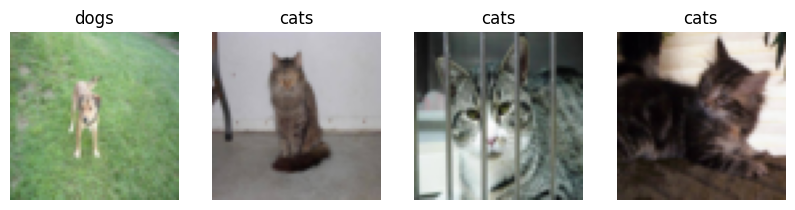

In [ ]:
if train_dataset is None or test_dataset is None:
    print("[BELUM SEDIA] Load dataset dahulu.")
    train_loader = test_loader = None
else:
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    images, labels = next(iter(train_loader))
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    plt.figure(figsize=(10,4))
    for i in range(min(4, len(images))):
        image = images[i].permute(1,2,0)
        class_name = train_dataset.classes[labels[i].item()]
        plt.subplot(1,4,i+1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")
    plt.show()

# 6. FIX ME: Build CatDogCNN Model

In [ ]:
INPUT_CHANNELS = 3
OUTPUT_CLASSES = 2

class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        if INPUT_CHANNELS is None or OUTPUT_CLASSES is None:
            raise ValueError("Lengkapkan INPUT_CHANNELS dan OUTPUT_CLASSES dahulu.")
        self.features = nn.Sequential(
            nn.Conv2d(INPUT_CHANNELS, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 8 * 8, 128), nn.ReLU(), nn.Linear(128, OUTPUT_CLASSES)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

try:
    model = CatDogCNN().to(device)
    print(model)
except Exception as e:
    model = None
    print("[BELUM LENGKAP]", e)

CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


# 7. FIX ME: Training Setup

In [ ]:
if model is None:
    print("[BELUM SEDIA] Lengkapkan model dahulu.")
    criterion = optimizer = epochs = None
else:
    criterion = nn.CrossEntropyLoss()  # FIX ME: nn.CrossEntropyLoss()
    optimizer =optim.Adam(model.parameters(), lr=0.001)   # FIX ME: optim.Adam(model.parameters(), lr=0.001)
    epochs = 30    # FIX ME: 3
    if criterion is None or optimizer is None or epochs is None:
        print("[BELUM LENGKAP] Lengkapkan criterion, optimizer dan epochs.")

# 8. Train Model

In [ ]:
if model is None or train_loader is None or criterion is None or optimizer is None or epochs is None:
    print("[BELUM SEDIA] Lengkapkan dataset, model dan training setup dahulu.")
    training_complete = False
else:
    for epoch in range(epochs):
        model.train(); running_loss = 0.0; correct = 0; total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item(); total += labels.size(0)
        accuracy = correct / total if total else 0
        print(f"Epoch {epoch+1}/{epochs}: Loss={running_loss:.4f}, Accuracy={accuracy:.4f}")
    training_complete = True

Epoch 1/30: Loss=2.5784, Accuracy=0.8417
Epoch 2/30: Loss=2.1195, Accuracy=0.9000
Epoch 3/30: Loss=1.8821, Accuracy=0.9083
Epoch 4/30: Loss=1.9295, Accuracy=0.8833
Epoch 5/30: Loss=1.8136, Accuracy=0.9000
Epoch 6/30: Loss=2.3060, Accuracy=0.8917
Epoch 7/30: Loss=1.5536, Accuracy=0.9333
Epoch 8/30: Loss=1.7445, Accuracy=0.9000
Epoch 9/30: Loss=1.6297, Accuracy=0.9250
Epoch 10/30: Loss=1.1699, Accuracy=0.9583
Epoch 11/30: Loss=1.1084, Accuracy=0.9583
Epoch 12/30: Loss=1.1088, Accuracy=0.9417
Epoch 13/30: Loss=0.9816, Accuracy=0.9583
Epoch 14/30: Loss=0.7442, Accuracy=0.9667
Epoch 15/30: Loss=0.6321, Accuracy=0.9750
Epoch 16/30: Loss=0.7914, Accuracy=0.9667
Epoch 17/30: Loss=0.6646, Accuracy=0.9667
Epoch 18/30: Loss=0.7309, Accuracy=0.9667
Epoch 19/30: Loss=0.6088, Accuracy=0.9917
Epoch 20/30: Loss=0.5582, Accuracy=0.9917
Epoch 21/30: Loss=0.5220, Accuracy=0.9833
Epoch 22/30: Loss=0.6204, Accuracy=0.9833
Epoch 23/30: Loss=0.7111, Accuracy=0.9750
Epoch 24/30: Loss=0.5625, Accuracy=0.9833
E

# 9. Evaluate and Predict

Test Accuracy: 0.6869


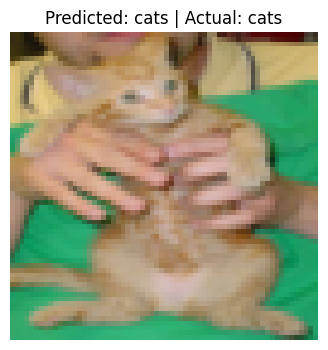

Predicted: cats
Actual   : cats


In [ ]:
if not globals().get("training_complete", False):
    print("[BELUM SEDIA] Train model dahulu.")
else:
    model.eval(); correct = 0; total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item(); total += labels.size(0)
    test_accuracy = correct / total if total else 0
    print("Test Accuracy:", f"{test_accuracy:.4f}")
    image, actual_label = test_dataset[1]
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        predicted_label = torch.argmax(output, dim=1).item()
    predicted_class = test_dataset.classes[predicted_label]
    actual_class = test_dataset.classes[actual_label]
    plt.figure(figsize=(4,4))
    plt.imshow(image.permute(1,2,0))
    plt.title(f"Predicted: {predicted_class} | Actual: {actual_class}")
    plt.axis("off")
    plt.show()
    print("Predicted:", predicted_class)
    print("Actual   :", actual_class)

In [ ]:
import os
import torch

save_dir = "/content/drive/MyDrive/Colab Notebooks"
save_path = os.path.join(save_dir, "kvtron_catdog_cnn_model.pth")

if globals().get("training_complete", False):
    os.makedirs(save_dir, exist_ok=True)

    torch.save(model.state_dict(), save_path)

    print("Model disimpan sebagai:", save_path)
else:
    print("Model belum disimpan kerana training_complete masih False.")

Model disimpan sebagai: /content/drive/MyDrive/Colab Notebooks/kvtron_catdog_cnn_model.pth


In [ ]:
import matplotlib.pyplot as plt

# Pastikan pemboleh ubah ini dipenuhi daripada gelung latihan anda:
# train_losses, val_losses, train_accs, val_accs

epochs = range(1, len(train_losses) + 1)

# Mencipta kanvas dengan 2 sub-plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Graf Loss
ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs, val_losses, 'r-s', label='Validation Loss')
ax1.set_title('Prestasi Loss (Model Cost)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot 2: Graf Accuracy
ax2.plot(epochs, train_accs, 'b-o', label='Train Accuracy')
ax2.plot(epochs, val_accs, 'r-s', label='Validation Accuracy')
ax2.set_title('Prestasi Ketepatan (Accuracy)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Ketepatan (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'train_losses' is not defined

# Reflection Bahagian 4
1. Mengapa Cat/Dog images menggunakan `Conv2d(3,...)`?  
   **Jawapan:**  
2. Mengapa dataset perlu disusun dalam folder `train/cats`, `train/dogs`, `test/cats`, `test/dogs`?  
   **Jawapan:**  
3. Mengapa semua imej perlu di-resize kepada `64 x 64`?  
   **Jawapan:**  
4. Apakah fungsi `RandomHorizontalFlip()`?  
   **Jawapan:**  
5. Mengapa accuracy mungkin rendah jika dataset kecil?  
   **Jawapan:**  

# Checkpoint Bahagian 4
| Evidence | Status |
|---|---|
| Google Drive mounted | ☐ |
| Dataset path detected | ☐ |
| `cats` and `dogs` folders detected | ☐ |
| ImageFolder loaded | ☐ |
| Class mapping displayed | ☐ |
| Sample images visualised | ☐ |
| CatDogCNN model printed | ☐ |
| Training loss displayed | ☐ |
| Test accuracy displayed | ☐ |
| One prediction visualised | ☐ |